# 🚢 Task 1: Titanic Survival Classification
**Data Science Internship | Machine Learning Project**

---

## 📋 Project Overview

The Titanic dataset is one of the most famous datasets in machine learning. The goal is to build a classification model that predicts whether a passenger **survived (1)** or **did not survive (0)** the Titanic disaster based on features like age, gender, ticket class, and fare.

### Workflow:
1. Import Libraries
2. Load & Explore Data
3. Exploratory Data Analysis (EDA)
4. Data Cleaning & Preprocessing
5. Feature Engineering
6. Model Training
7. Model Evaluation
8. Feature Importance & Insights

---

## Step 1: Import Libraries

We import all the necessary Python libraries upfront:
- **pandas & numpy** — Data manipulation and numerical operations
- **matplotlib & seaborn** — Data visualization
- **sklearn** — Machine learning tools: preprocessing, models, and evaluation metrics

In [ ]:
# ── Core Data Libraries ──
import pandas as pd
import numpy as np

# ── Visualization Libraries ──
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# ── Scikit-learn: Preprocessing ──
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# ── Scikit-learn: Models ──
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# ── Scikit-learn: Evaluation ──
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)

# ── Settings ──
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.max_columns', 20)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


---
## Step 2: Load & Explore the Dataset

We load the Titanic CSV file and perform an initial exploration to understand:
- The **shape** of the data (rows × columns)
- The **data types** of each column
- The presence of **missing values**
- Basic **descriptive statistics**

> 📌 **Note:** Upload the `Titanic-Dataset.csv` file to your Colab session via the Files panel on the left, or use the Kaggle API to download it directly.

In [ ]:
# ── Load the dataset ──
# If using Colab, upload the file first OR use:
# from google.colab import files; files.upload()

df = pd.read_csv('/content/Titanic-Dataset.csv')

print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("\n── First 5 Rows ──")
df.head()

Dataset Shape: 891 rows × 12 columns

── First 5 Rows ──


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# ── Column data types and non-null counts ──
print("── Dataset Info ──")
df.info()

── Dataset Info ──
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
# ── Descriptive statistics for numerical columns ──
# This gives us count, mean, std, min, quartiles, and max
print("── Descriptive Statistics ──")
df.describe().round(2)

── Descriptive Statistics ──


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,714.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.70,0.52,0.38,32.20
std,257.35,0.49,0.84,14.53,1.10,0.81,49.69
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,223.50,0.00,2.00,20.12,0.00,0.00,7.91
50%,446.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,668.50,1.00,3.00,38.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33


── Missing Values ──
          Missing Count  Missing %
Age                 177      19.87
Cabin               687      77.10
Embarked              2       0.22


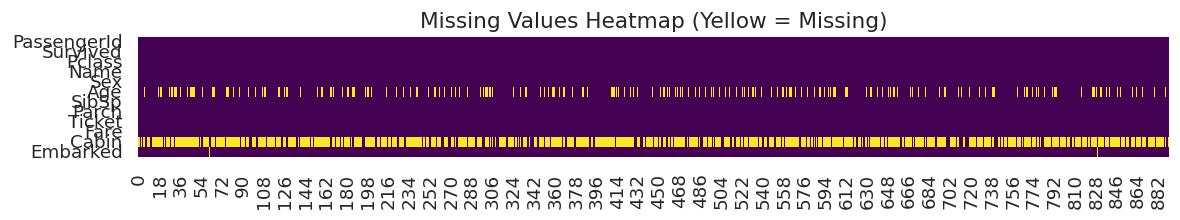

In [ ]:
# ── Check for missing values ──
# Missing data can significantly affect model performance if not handled properly
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0')

print("── Missing Values ──")
print(missing_df)

# Visual: Missing values heatmap
fig, ax = plt.subplots(figsize=(10, 2))
sns.heatmap(df.isnull().T, cbar=False, cmap='viridis', yticklabels=df.columns, ax=ax)
ax.set_title('Missing Values Heatmap (Yellow = Missing)', fontsize=13)
plt.tight_layout()
plt.show()

### 🔍 Initial Observations
- **Age** has ~177 missing values (19.9%) — needs imputation
- **Cabin** has ~687 missing values (77.1%) — too many to impute; we'll drop it
- **Embarked** has only 2 missing values — easy to fill with the mode
- **Target Variable**: `Survived` (0 = Did not survive, 1 = Survived)

---
## Step 3: Exploratory Data Analysis (EDA)

EDA helps us visually understand patterns in the data before building any model. We look at:
- **Survival distribution** (class imbalance check)
- **Survival by gender** — a historically well-known factor ("women and children first")
- **Survival by passenger class** — 1st class had more lifeboats access
- **Age distribution** — younger passengers may have had higher survival rates
- **Fare distribution** — higher-paying passengers were in better decks

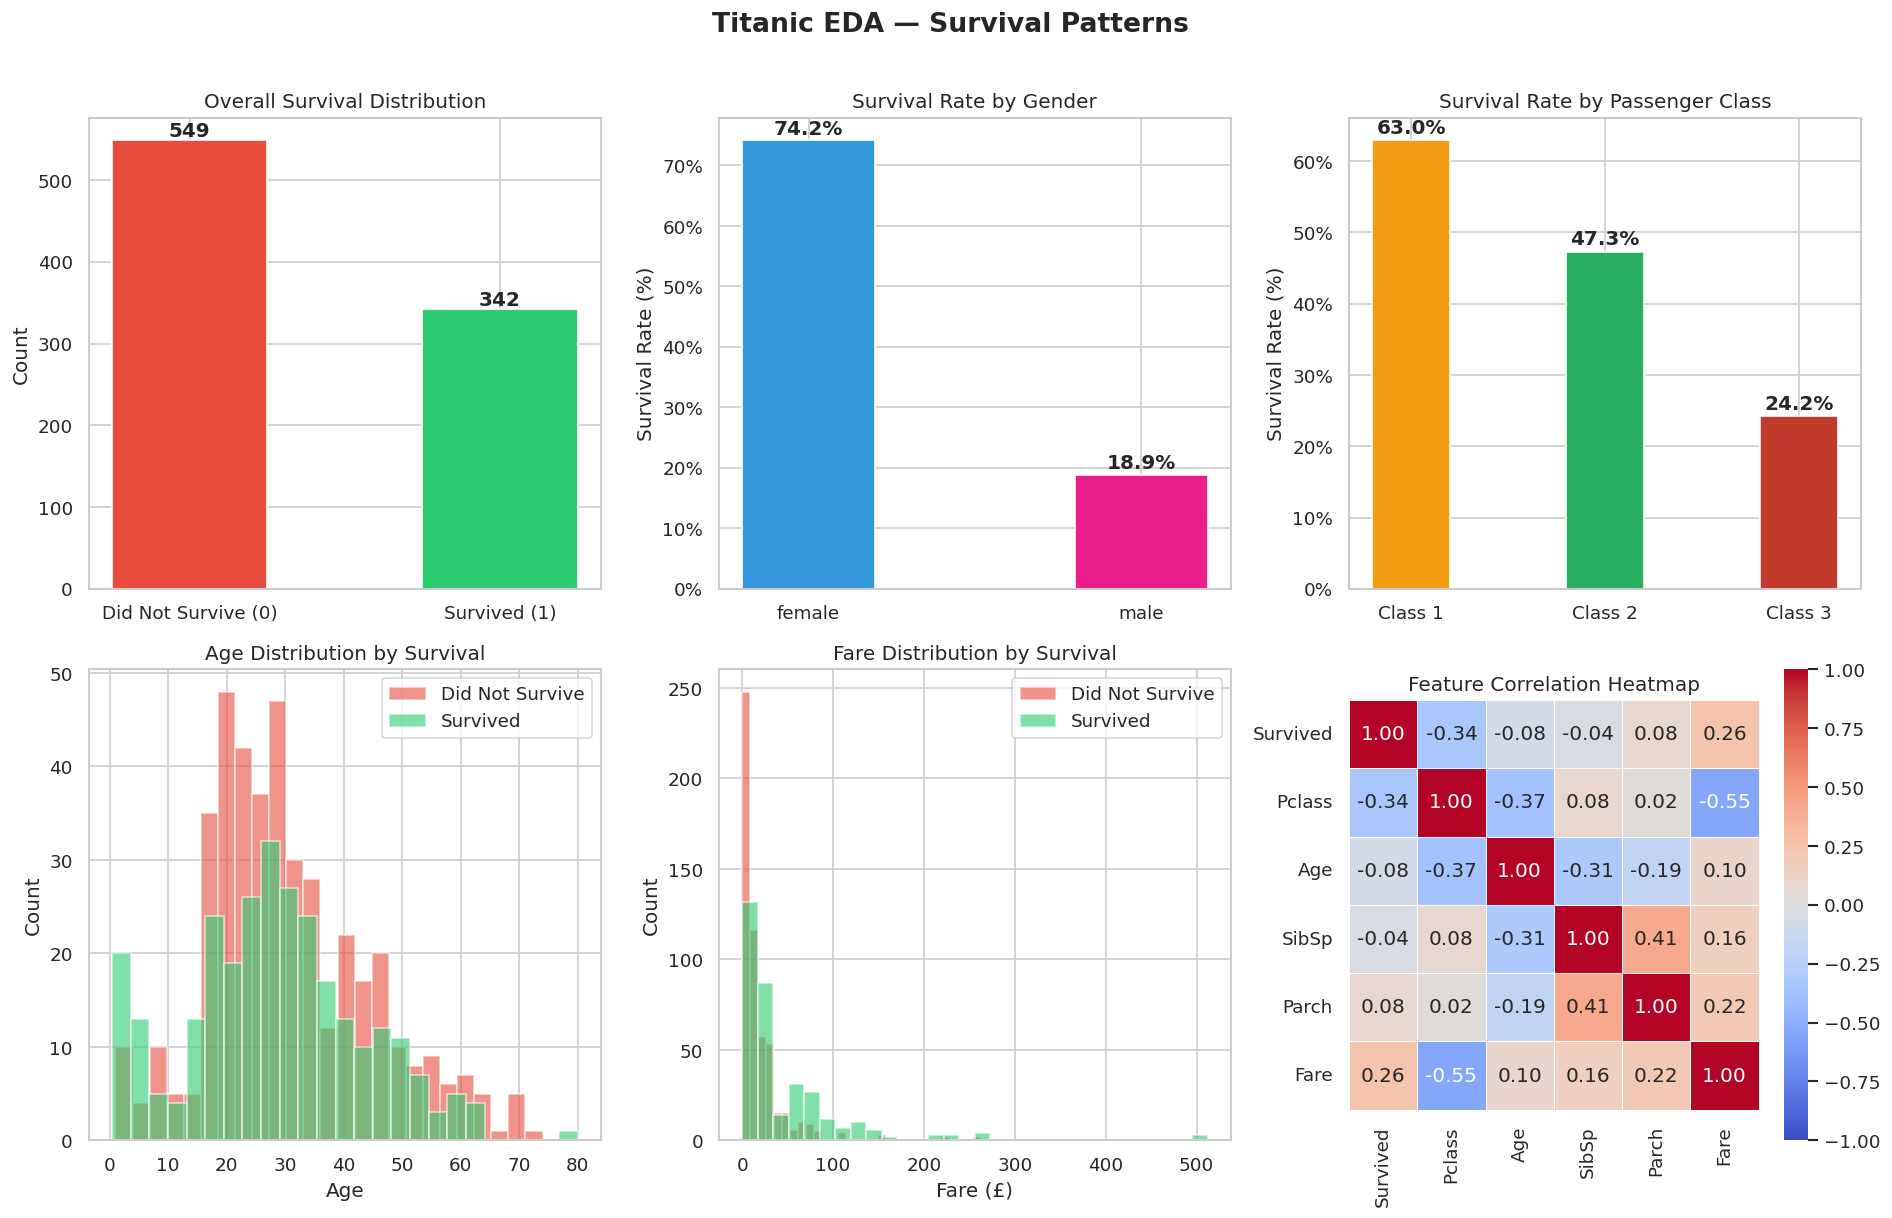

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Titanic EDA — Survival Patterns', fontsize=16, fontweight='bold', y=1.01)

# ── 1. Survival Count ──
survival_counts = df['Survived'].value_counts()
axes[0, 0].bar(['Did Not Survive (0)', 'Survived (1)'],
               survival_counts.values,
               color=['#e74c3c', '#2ecc71'], edgecolor='white', width=0.5)
axes[0, 0].set_title('Overall Survival Distribution')
axes[0, 0].set_ylabel('Count')
for i, v in enumerate(survival_counts.values):
    axes[0, 0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# ── 2. Survival by Gender ──
gender_survival = df.groupby('Sex')['Survived'].mean() * 100
axes[0, 1].bar(gender_survival.index, gender_survival.values,
               color=['#3498db', '#e91e8c'], edgecolor='white', width=0.4)
axes[0, 1].set_title('Survival Rate by Gender')
axes[0, 1].set_ylabel('Survival Rate (%)')
axes[0, 1].yaxis.set_major_formatter(mtick.PercentFormatter())
for i, v in enumerate(gender_survival.values):
    axes[0, 1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

# ── 3. Survival by Pclass ──
pclass_survival = df.groupby('Pclass')['Survived'].mean() * 100
axes[0, 2].bar([f'Class {i}' for i in pclass_survival.index], pclass_survival.values,
               color=['#f39c12', '#27ae60', '#c0392b'], edgecolor='white', width=0.4)
axes[0, 2].set_title('Survival Rate by Passenger Class')
axes[0, 2].set_ylabel('Survival Rate (%)')
axes[0, 2].yaxis.set_major_formatter(mtick.PercentFormatter())
for i, v in enumerate(pclass_survival.values):
    axes[0, 2].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

# ── 4. Age Distribution by Survival ──
df[df['Survived'] == 0]['Age'].dropna().hist(ax=axes[1, 0], bins=25, alpha=0.6,
                                              color='#e74c3c', label='Did Not Survive')
df[df['Survived'] == 1]['Age'].dropna().hist(ax=axes[1, 0], bins=25, alpha=0.6,
                                              color='#2ecc71', label='Survived')
axes[1, 0].set_title('Age Distribution by Survival')
axes[1, 0].set_xlabel('Age')
axes[1, 0].set_ylabel('Count')
axes[1, 0].legend()

# ── 5. Fare Distribution by Survival ──
df[df['Survived'] == 0]['Fare'].hist(ax=axes[1, 1], bins=30, alpha=0.6,
                                      color='#e74c3c', label='Did Not Survive')
df[df['Survived'] == 1]['Fare'].hist(ax=axes[1, 1], bins=30, alpha=0.6,
                                      color='#2ecc71', label='Survived')
axes[1, 1].set_title('Fare Distribution by Survival')
axes[1, 1].set_xlabel('Fare (£)')
axes[1, 1].set_ylabel('Count')
axes[1, 1].legend()

# ── 6. Correlation Heatmap ──
num_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[1, 2], linewidths=0.5, square=True, vmin=-1, vmax=1)
axes[1, 2].set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()

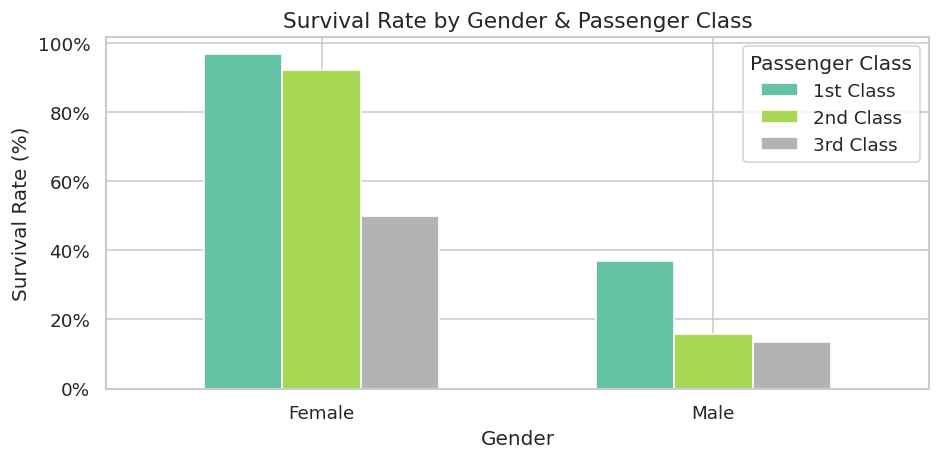

Pclass     1     2     3
Sex                     
female  96.8  92.1  50.0
male    36.9  15.7  13.5


In [ ]:
# ── Survival Rate by Gender AND Class (interaction effect) ──
pivot = df.pivot_table(values='Survived', index='Sex', columns='Pclass', aggfunc='mean') * 100

fig, ax = plt.subplots(figsize=(8, 4))
pivot.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white', width=0.6)
ax.set_title('Survival Rate by Gender & Passenger Class', fontsize=13)
ax.set_ylabel('Survival Rate (%)')
ax.set_xlabel('Gender')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(title='Passenger Class', labels=['1st Class', '2nd Class', '3rd Class'])
ax.set_xticklabels(['Female', 'Male'], rotation=0)
plt.tight_layout()
plt.show()

print(pivot.round(1).to_string())

### 💡 Key EDA Insights
- **Gender is the strongest predictor**: ~74% of females survived vs ~19% of males
- **Class matters significantly**: 1st class passengers had ~63% survival rate vs 24% for 3rd class
- **Fare correlates positively with survival**: higher fares → higher class → more access to lifeboats
- **Pclass correlates negatively with survival** (class 1 = best, class 3 = worst)

---
## Step 4: Data Cleaning & Preprocessing

Raw data is rarely ready for ML. We must:
1. **Drop irrelevant columns** — `PassengerId`, `Name`, `Ticket`, `Cabin` don't help prediction
2. **Handle missing values** — Impute `Age` with median (robust to outliers), fill `Embarked` with mode
3. **Encode categorical variables** — Convert `Sex` and `Embarked` from strings to numbers

> 🔑 **Why median for Age?** The Age distribution is slightly right-skewed (outliers like elderly passengers). Median is more robust than mean in this case.

In [ ]:
# ── Work on a copy to preserve the original data ──
df_clean = df.copy()

# ── Step 4.1: Drop irrelevant columns ──
# PassengerId: just a row index
# Name: free-text, too complex without advanced NLP
# Ticket: alphanumeric codes with no clear pattern
# Cabin: 77% missing — not useful
cols_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']
df_clean.drop(columns=cols_to_drop, inplace=True)
print(f"Dropped columns: {cols_to_drop}")
print(f"Remaining columns: {list(df_clean.columns)}")

Dropped columns: ['PassengerId', 'Name', 'Ticket', 'Cabin']
Remaining columns: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


In [ ]:
# ── Step 4.2: Handle missing values ──

# Age: impute with median (robust against outliers)
age_median = df_clean['Age'].median()
df_clean['Age'].fillna(age_median, inplace=True)
print(f"Age — filled {df['Age'].isnull().sum()} missing values with median = {age_median}")

# Embarked: impute with mode (most frequent port)
embarked_mode = df_clean['Embarked'].mode()[0]
df_clean['Embarked'].fillna(embarked_mode, inplace=True)
print(f"Embarked — filled {df['Embarked'].isnull().sum()} missing values with mode = '{embarked_mode}'")

# Verify no missing values remain
print(f"\nMissing values remaining: {df_clean.isnull().sum().sum()} ✅")

Age — filled 177 missing values with median = 28.0
Embarked — filled 2 missing values with mode = 'S'

Missing values remaining: 0 ✅


In [ ]:
# ── Step 4.3: Encode categorical variables ──
# ML models work with numbers, not strings.
# For binary categories (Sex), we use Label Encoding (0/1).
# For multi-category (Embarked with 3 values), we use One-Hot Encoding
# to avoid implying an ordinal relationship (S=2 > Q=1 is meaningless).

# Label encode Sex: male → 0, female → 1
le = LabelEncoder()
df_clean['Sex'] = le.fit_transform(df_clean['Sex'])
print(f"Sex encoded — classes: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# One-Hot encode Embarked (drop_first=True avoids the dummy variable trap)
df_clean = pd.get_dummies(df_clean, columns=['Embarked'], drop_first=True)
print(f"Embarked one-hot encoded — new columns: {[c for c in df_clean.columns if 'Embarked' in c]}")

print(f"\nFinal dataset shape: {df_clean.shape}")
df_clean.head()

Sex encoded — classes: {'female': np.int64(0), 'male': np.int64(1)}
Embarked one-hot encoded — new columns: ['Embarked_Q', 'Embarked_S']

Final dataset shape: (891, 9)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,1,22.0,1,0,7.2500,False,True
1,1,1,0,38.0,1,0,71.2833,False,False
2,1,3,0,26.0,0,0,7.9250,False,True
3,1,1,0,35.0,1,0,53.1000,False,True
4,0,3,1,35.0,0,0,8.0500,False,True


---
## Step 5: Feature Engineering

Feature engineering creates **new meaningful features** from existing ones, helping models learn better patterns.

We create:
- **`FamilySize`** = SibSp + Parch + 1 (yourself): passengers traveling alone may behave differently from those with family
- **`IsAlone`**: a binary flag — traveling alone is a strong signal
- **`AgeGroup`**: binning continuous age into meaningful life-stage categories reduces noise

In [ ]:
# ── Feature 1: Family Size ──
# SibSp = siblings/spouses aboard; Parch = parents/children aboard
df_clean['FamilySize'] = df_clean['SibSp'] + df_clean['Parch'] + 1

# ── Feature 2: Is Alone ──
# Solo travelers may have been more agile or had less reason to wait
df_clean['IsAlone'] = (df_clean['FamilySize'] == 1).astype(int)

# ── Feature 3: Age Group (binning) ──
# Continuous age is noisy; grouping by life stage captures meaningful patterns
bins = [0, 12, 18, 35, 60, 100]
labels = [0, 1, 2, 3, 4]  # Child, Teen, Young Adult, Adult, Senior
df_clean['AgeGroup'] = pd.cut(df_clean['Age'], bins=bins, labels=labels).astype(int)

# Quick check of survival rates by new features
print("Survival rate by IsAlone:")
print((df_clean.groupby('IsAlone')['Survived'].mean() * 100).round(1).to_string())
print("\nSurvival rate by FamilySize:")
print((df_clean.groupby('FamilySize')['Survived'].mean() * 100).round(1).to_string())
print(f"\nFinal feature set shape: {df_clean.shape}")
print(f"Features: {list(df_clean.columns)}")

Survival rate by IsAlone:
IsAlone
0    50.6
1    30.4

Survival rate by FamilySize:
FamilySize
1     30.4
2     55.3
3     57.8
4     72.4
5     20.0
6     13.6
7     33.3
8      0.0
11     0.0

Final feature set shape: (891, 12)
Features: ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S', 'FamilySize', 'IsAlone', 'AgeGroup']


---
## Step 6: Prepare Data for Modeling

We split the data into:
- **Feature matrix X** — all input columns
- **Target vector y** — the `Survived` column

Then apply an **80/20 train-test split** with `stratify=y` to ensure both splits have similar class proportions (important for imbalanced data).

Finally, we apply **StandardScaler** to normalize features. This is critical for distance-based models (KNN, SVM, Logistic Regression) where features with large ranges (like Fare) would otherwise dominate.

In [ ]:
# ── Define features and target ──
X = df_clean.drop('Survived', axis=1)
y = df_clean['Survived']

print(f"Features (X): {X.shape}  →  {list(X.columns)}")
print(f"Target  (y): {y.shape}  →  Classes: {y.value_counts().to_dict()}")

# ── Train-Test Split ──
# test_size=0.2  → 20% held out for final evaluation
# stratify=y     → maintains the same class ratio in both splits
# random_state   → ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set:   {X_train.shape[0]} samples")
print(f"Test set:       {X_test.shape[0]} samples")

# ── Feature Scaling ──
# StandardScaler transforms each feature to have mean=0 and std=1
# Fitted ONLY on training data to prevent data leakage
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit + transform on train
X_test_sc  = scaler.transform(X_test)         # transform only on test

print("\n✅ Train-test split and scaling complete!")

Features (X): (891, 11)  →  ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S', 'FamilySize', 'IsAlone', 'AgeGroup']
Target  (y): (891,)  →  Classes: {0: 549, 1: 342}

Training set:   712 samples
Test set:       179 samples

✅ Train-test split and scaling complete!


---
## Step 7: Train & Compare Multiple Models

We train **6 different classifiers** to compare their performance:

| Model | Type | Key Idea |
|---|---|---|
| Logistic Regression | Linear | Finds a linear decision boundary using probabilities |
| Decision Tree | Tree-based | Splits data using if-else rules on features |
| Random Forest | Ensemble | Averages many Decision Trees (reduces overfitting) |
| Gradient Boosting | Ensemble | Builds trees sequentially, each correcting prior errors |
| SVM | Kernel-based | Finds the maximum-margin hyperplane between classes |
| K-Nearest Neighbors | Distance-based | Classifies by majority vote of nearest k neighbors |

We use **5-Fold Stratified Cross-Validation** for a fair comparison — this prevents overfitting to a single train-test split.

In [ ]:
# ── Define models ──
models = {
    'Logistic Regression':   LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':         DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest':         RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':     GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM':                   SVC(kernel='rbf', probability=True, random_state=42),
    'K-Nearest Neighbors':   KNeighborsClassifier(n_neighbors=5)
}

# ── 5-Fold Stratified Cross Validation ──
# StratifiedKFold ensures each fold preserves the class ratio
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}
print(f"{'Model':<25} {'CV Mean Acc':>12} {'CV Std':>10} {'Test Acc':>10}")
print("-" * 62)

for name, model in models.items():
    # Cross-validation on training set
    cv_scores = cross_val_score(model, X_train_sc, y_train, cv=cv, scoring='accuracy')

    # Final fit on all training data and evaluate on held-out test set
    model.fit(X_train_sc, y_train)
    y_pred = model.predict(X_test_sc)
    test_acc = accuracy_score(y_test, y_pred)

    results[name] = {
        'model': model,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'test_acc': test_acc,
        'y_pred': y_pred
    }
    print(f"{name:<25} {cv_scores.mean():>11.4f} {cv_scores.std():>10.4f} {test_acc:>10.4f}")

Model                      CV Mean Acc     CV Std   Test Acc
--------------------------------------------------------------
Logistic Regression            0.8048     0.0119     0.8045
Decision Tree                  0.8048     0.0092     0.7598
Random Forest                  0.8020     0.0136     0.8268
Gradient Boosting              0.8244     0.0312     0.8045
SVM                            0.8258     0.0237     0.8212
K-Nearest Neighbors            0.7837     0.0115     0.8156


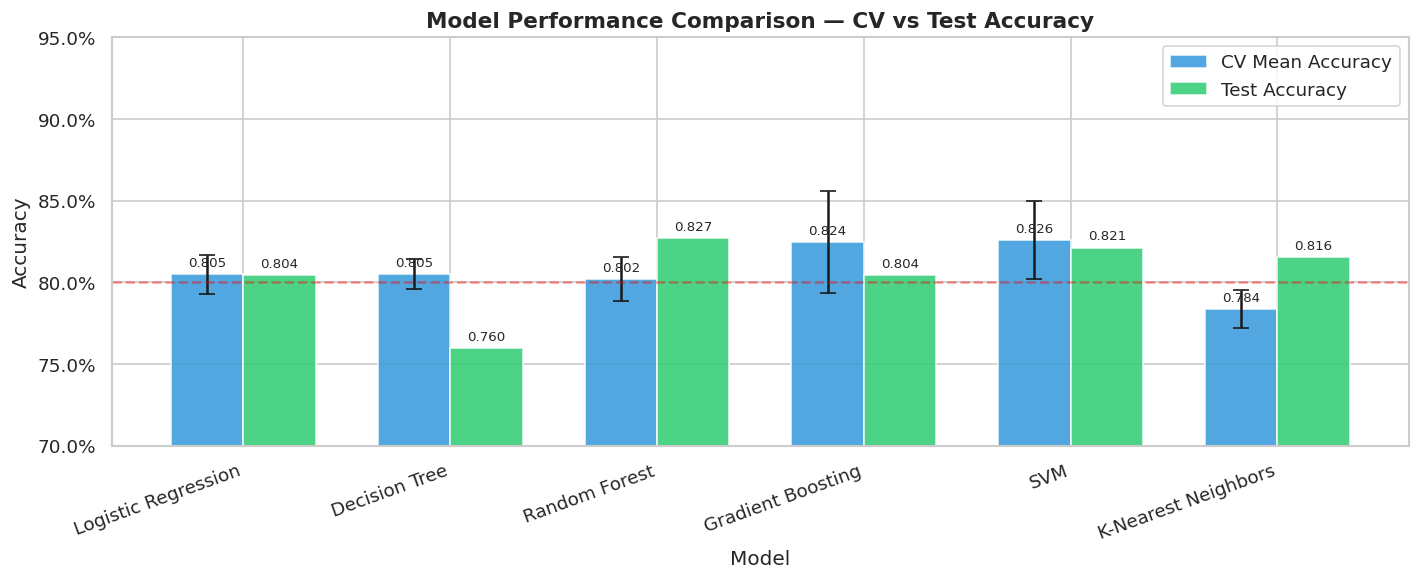

In [ ]:
# ── Visualize model comparison ──
model_names = list(results.keys())
cv_means    = [results[m]['cv_mean'] for m in model_names]
cv_stds     = [results[m]['cv_std']  for m in model_names]
test_accs   = [results[m]['test_acc'] for m in model_names]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, cv_means, width, yerr=cv_stds,
               label='CV Mean Accuracy', color='#3498db', alpha=0.85,
               capsize=5, edgecolor='white')
bars2 = ax.bar(x + width/2, test_accs, width,
               label='Test Accuracy', color='#2ecc71', alpha=0.85, edgecolor='white')

ax.set_xlabel('Model')
ax.set_ylabel('Accuracy')
ax.set_title('Model Performance Comparison — CV vs Test Accuracy', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=20, ha='right')
ax.set_ylim(0.7, 0.95)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend()
ax.axhline(y=0.8, color='red', linestyle='--', alpha=0.4, label='80% baseline')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

---
## Step 8: Deep Evaluation of the Best Model

We select the best-performing model (highest test accuracy) and evaluate it thoroughly using:

- **Confusion Matrix** — shows True Positives, True Negatives, False Positives, False Negatives
- **Classification Report** — Precision, Recall, and F1-Score per class
- **ROC Curve & AUC** — measures the model's ability to discriminate between classes across all thresholds

> 🔑 **Precision** = Of all predicted survivors, how many actually survived?  
> 🔑 **Recall** = Of all actual survivors, how many did we correctly identify?  
> 🔑 **F1-Score** = Harmonic mean of Precision and Recall (best when classes are imbalanced)  
> 🔑 **AUC** = Area Under ROC Curve — 1.0 is perfect, 0.5 is random guessing

In [ ]:
# ── Select the best model ──
best_name = max(results, key=lambda m: results[m]['test_acc'])
best = results[best_name]
print(f"🏆 Best Model: {best_name}")
print(f"   Test Accuracy: {best['test_acc']:.4f} ({best['test_acc']*100:.2f}%)")
print(f"   CV Mean Accuracy: {best['cv_mean']:.4f} ± {best['cv_std']:.4f}")

🏆 Best Model: Random Forest
   Test Accuracy: 0.8268 (82.68%)
   CV Mean Accuracy: 0.8020 ± 0.0136


In [ ]:
# ── Classification Report ──
print("── Classification Report ──")
print(classification_report(y_test, best['y_pred'],
                             target_names=['Did Not Survive', 'Survived']))

── Classification Report ──
                 precision    recall  f1-score   support

Did Not Survive       0.85      0.87      0.86       110
       Survived       0.79      0.75      0.77        69

       accuracy                           0.83       179
      macro avg       0.82      0.81      0.82       179
   weighted avg       0.83      0.83      0.83       179



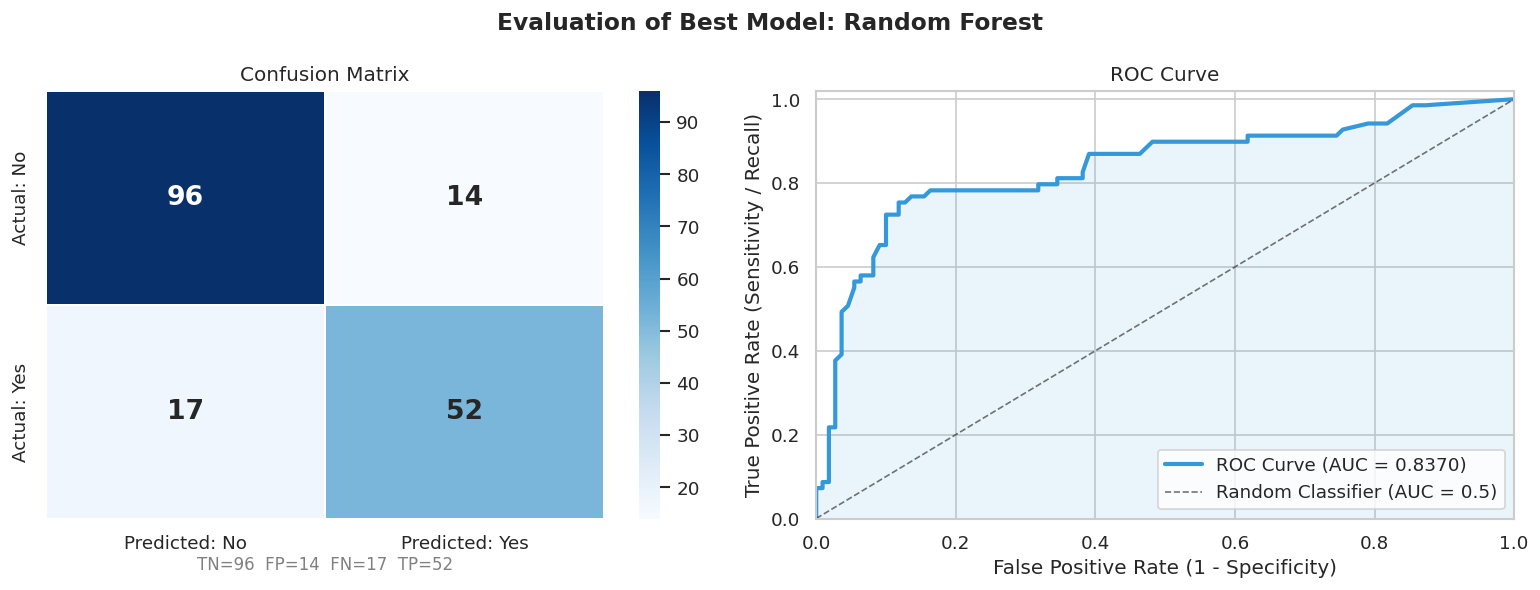

In [ ]:
# ── Confusion Matrix + ROC Curve (side by side) ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Evaluation of Best Model: {best_name}', fontsize=14, fontweight='bold')

# ── Confusion Matrix ──
cm = confusion_matrix(y_test, best['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: No', 'Predicted: Yes'],
            yticklabels=['Actual: No', 'Actual: Yes'],
            ax=axes[0], linewidths=1, linecolor='white',
            annot_kws={'size': 16, 'weight': 'bold'})
axes[0].set_title('Confusion Matrix', fontsize=12)

# Annotate quadrants
tn, fp, fn, tp = cm.ravel()
axes[0].text(0.5, -0.12,
    f'TN={tn}  FP={fp}  FN={fn}  TP={tp}',
    ha='center', transform=axes[0].transAxes, fontsize=10, color='gray')

# ── ROC Curve ──
y_prob = best['model'].predict_proba(X_test_sc)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

axes[1].plot(fpr, tpr, color='#3498db', lw=2.5,
             label=f'ROC Curve (AUC = {auc_score:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.6, label='Random Classifier (AUC = 0.5)')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#3498db')
axes[1].set_xlabel('False Positive Rate (1 - Specificity)')
axes[1].set_ylabel('True Positive Rate (Sensitivity / Recall)')
axes[1].set_title('ROC Curve', fontsize=12)
axes[1].legend(loc='lower right')
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

plt.tight_layout()
plt.show()

---
## Step 9: Feature Importance

Understanding **which features matter most** is crucial for:
- Interpreting model decisions
- Reducing feature dimensionality in future work
- Communicating insights to stakeholders

Tree-based models (Random Forest, Gradient Boosting) provide **built-in feature importance scores** based on how much each feature reduces impurity across all trees.

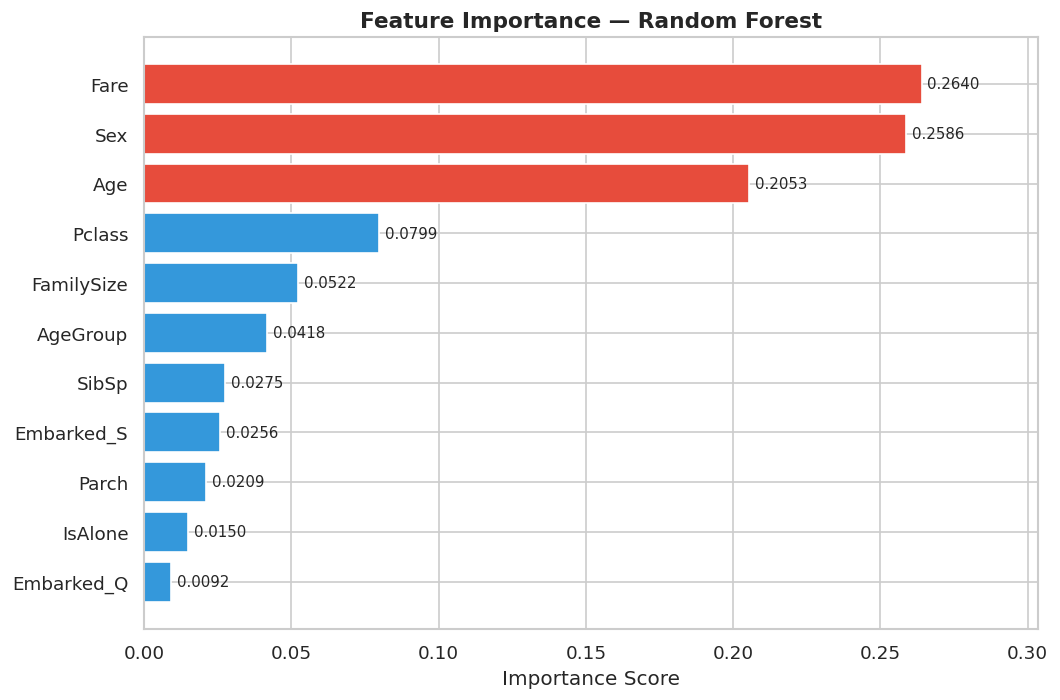


Top 3 Most Important Features:
Feature  Importance
   Fare    0.264008
    Sex    0.258645
    Age    0.205299


In [ ]:
# ── Feature Importance (use Random Forest if best model doesn't have it) ──
if hasattr(best['model'], 'feature_importances_'):
    importance_model = best['model']
    importance_model_name = best_name
else:
    # Fall back to Random Forest which always has feature importances
    importance_model = results['Random Forest']['model']
    importance_model_name = 'Random Forest'
    print(f"Note: {best_name} doesn't have feature_importances_. Using Random Forest instead.")

feature_names = list(X.columns)
importances = importance_model.feature_importances_

feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True)

# ── Plot ──
fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#e74c3c' if imp > feat_imp_df['Importance'].quantile(0.75) else '#3498db'
          for imp in feat_imp_df['Importance']]
bars = ax.barh(feat_imp_df['Feature'], feat_imp_df['Importance'],
               color=colors, edgecolor='white')

for bar, val in zip(bars, feat_imp_df['Importance']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_title(f'Feature Importance — {importance_model_name}', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.set_xlim(0, feat_imp_df['Importance'].max() * 1.15)
plt.tight_layout()
plt.show()

print("\nTop 3 Most Important Features:")
print(feat_imp_df.sort_values('Importance', ascending=False).head(3).to_string(index=False))

---
## Step 10: Final Summary

Let's print a clean summary of all model performances and key takeaways.

In [ ]:
# ── Final Performance Summary Table ──
summary_df = pd.DataFrame([
    {
        'Model': name,
        'CV Mean Accuracy': f"{res['cv_mean']*100:.2f}%",
        'CV Std': f"±{res['cv_std']*100:.2f}%",
        'Test Accuracy': f"{res['test_acc']*100:.2f}%",
        'ROC AUC': f"{roc_auc_score(y_test, res['model'].predict_proba(X_test_sc)[:, 1]):.4f}"
    }
    for name, res in results.items()
])

summary_df = summary_df.sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
print("\n🏆 Final Model Performance Summary")
print("=" * 75)
print(summary_df.to_string(index=False))
print("=" * 75)
print(f"\n✅ Best Model: {best_name}")
print(f"   Test Accuracy: {best['test_acc']*100:.2f}%")
print(f"   ROC AUC: {roc_auc_score(y_test, best['model'].predict_proba(X_test_sc)[:, 1]):.4f}")


🏆 Final Model Performance Summary
              Model CV Mean Accuracy CV Std Test Accuracy ROC AUC
      Random Forest           80.20% ±1.36%        82.68%  0.8370
                SVM           82.58% ±2.37%        82.12%  0.8449
K-Nearest Neighbors           78.37% ±1.15%        81.56%  0.8475
Logistic Regression           80.48% ±1.19%        80.45%  0.8557
  Gradient Boosting           82.44% ±3.12%        80.45%  0.8209
      Decision Tree           80.48% ±0.92%        75.98%  0.8021

✅ Best Model: Random Forest
   Test Accuracy: 82.68%
   ROC AUC: 0.8370


In [ ]:
# ── Key Findings & Conclusions ──
print("""
TITANIC SURVIVAL CLASSIFICATION — CONCLUSIONS
============================================

📊 Dataset
- 891 passengers
- 12 features

🎯 Target
- Survived (0 = No, 1 = Yes)

🔑 Top Predictive Features
1. Sex — Females: 74% vs Males: 19%
2. Fare — Higher fare → better class → more lifeboats
3. Pclass — 1st class: 63% survival
4. Age — Children prioritized

🛠️ Preprocessing
- Dropped: PassengerId, Name, Ticket, Cabin
- Imputed: Age (median), Embarked (mode)
- Encoded: Sex (Label), Embarked (One-Hot)
- Engineered: FamilySize, IsAlone, AgeGroup
- Scaled: StandardScaler

📈 Models
- LR, DT, RF, GB, SVM, KNN

✅ Evaluation
- 5-Fold CV, Confusion Matrix, ROC AUC
""")


TITANIC SURVIVAL CLASSIFICATION — CONCLUSIONS

📊 Dataset
- 891 passengers
- 12 features

🎯 Target
- Survived (0 = No, 1 = Yes)

🔑 Top Predictive Features
1. Sex — Females: 74% vs Males: 19%
2. Fare — Higher fare → better class → more lifeboats
3. Pclass — 1st class: 63% survival
4. Age — Children prioritized

🛠️ Preprocessing
- Dropped: PassengerId, Name, Ticket, Cabin
- Imputed: Age (median), Embarked (mode)
- Encoded: Sex (Label), Embarked (One-Hot)
- Engineered: FamilySize, IsAlone, AgeGroup
- Scaled: StandardScaler

📈 Models
- LR, DT, RF, GB, SVM, KNN

✅ Evaluation
- 5-Fold CV, Confusion Matrix, ROC AUC

